## Import och Databehandling för potentiell evapotranspiration med pyet
*E. Haaf (Chalmers), 2026*

Detta skript läser klimatdata från klimatdata.csv och beräknar potentiell evapotranspiration (PET) med pyet. Skriptet:

1. Läser och förbereder klimatserier i daglig upplösning
2. Arrangerar data till ett gemensamt tidindex med nödvändiga variabler
3. Beräknar PET med pyet
4. Exporterar resultatet till en ren CSV-fil i data-mappen
5. Visualiserar en representativ PET-metod

### 0. Importera bibliotek

In [1]:
import os
import numpy
import pandas as pd
import matplotlib.pyplot as plt

import pyet

### 1. Ange platsparametrar

In [2]:
# Definiera latitude och marknivå för mätobjektet
latitude_deg = 58.70
elevation = 76.0

# Konvertera latitude från grader till radians för pyet
lat = float(latitude_deg) * numpy.pi / 180

print(f"Latitude: {latitude_deg} degrees ({lat:.4f} rad)")
print(f"Elevation: {elevation:.1f} m")

Latitude: 58.7 degrees (1.0245 rad)
Elevation: 76.0 m


### 2. Läs in klimatdata

In [4]:
# Ange filsökvägen till klimatdata
file_path = "../data/klimatdata.csv"

# Läs klimatdata och parsa datumkolumnen
df = pd.read_csv(file_path, parse_dates=["Datum"])

# Byt namn på kolumner till pyet-format
df = df.rename(
    columns={
        "Tmean": "tmean",
        "Tmax": "tmax",
        "Tmin": "tmin",
        "RHmean": "rh",
        "Rs": "rs",
        "Windmean": "wind",
    }
)

# Align Datasets: välj nödvändiga kolumner, sätt datum som index och sortera
df = df[["Datum", "tmean", "wind", "rs", "tmax", "tmin", "rh"]].copy()
df = df.set_index("Datum").sort_index()

# Hantera saknade värden och skapa slutlig indata
df = df.apply(pd.to_numeric, errors="coerce")
combined_data = df.dropna(subset=["tmean", "wind", "rs", "tmax", "tmin", "rh"]).copy()

print(f"Antal rader i indata: {len(df)}")
# Säkerställ ett komplett dagligt tidsindex utan luckor
first_complete = df.dropna(subset=["tmean", "wind", "rs", "tmax", "tmin", "rh"]).index.min()
full_idx = pd.date_range(first_complete, df.index.max(), freq="D")
df = df.reindex(full_idx)

# Fyll luckor med tidslinjär interpolation (temperatur, strålning, vind, fuktighet)
df = df.interpolate(method="time")
df = df.ffill().bfill()  # fyll eventuella kvarvarande NaN vid kanterna

# Skapa slutlig indata – nu alltid utan luckor
combined_data = df[["tmean", "wind", "rs", "tmax", "tmin", "rh"]].copy()

print(f"Antal rader i indata: {len(df)}")
print(f"Inferred freq: {pd.infer_freq(combined_data.index)}")  # bör vara 'D'
print(f"Saknade värden kvar: {combined_data.isna().sum().sum()}")
print(combined_data.head())

Antal rader i indata: 15676
Antal rader i indata: 10928
Inferred freq: D
Saknade värden kvar: 0
            tmean   wind       rs  tmax  tmin         rh
1996-01-01   -5.7  1.750  0.83448  -4.5  -7.7  99.000000
1996-01-02   -9.8  3.250  1.36116  -5.6 -11.8  99.024194
1996-01-03  -12.0  2.000  1.22616 -10.1 -14.0  99.048387
1996-01-04  -11.0  1.625  0.88848  -8.6 -13.2  99.072581
1996-01-05  -15.7  0.750  1.07172 -10.7 -19.0  99.096774


### 3. Beräkna potentiell evapotranspiration (PET)

In [5]:
# Calculate Potential Evapotranspiration (PE) using pyet
pet_results = pyet.calculate_all(
    tmean=combined_data["tmean"],
    wind=combined_data["wind"],
    rs=combined_data["rs"],
    elevation=elevation,
    lat=lat,
    tmax=combined_data["tmax"],
    tmin=combined_data["tmin"],
    rh=combined_data["rh"],
)

print("Beräkning klar. Tillgängliga PET-metoder:")
print(list(pet_results.columns))
print(pet_results.head())

Beräkning klar. Tillgängliga PET-metoder:
['Penman', 'FAO-56', 'Priestley-Taylor', 'Kimberly-Penman', 'Thom-Oliver', 'Blaney-Criddle', 'Hamon', 'Romanenko', 'Linacre', 'Haude', 'Turc', 'Jensen-Haise', 'Mcguinness-Bordne', 'Hargreaves', 'FAO-24', 'Abtew', 'Makkink', 'Oudin']
            Penman  FAO-56  Priestley-Taylor  Kimberly-Penman  Thom-Oliver  \
1996-01-01     0.0     0.0               0.0              0.0          0.0   
1996-01-02     0.0     0.0               0.0              0.0          0.0   
1996-01-03     0.0     0.0               0.0              0.0          0.0   
1996-01-04     0.0     0.0               0.0              0.0          0.0   
1996-01-05     0.0     0.0               0.0              0.0          0.0   

            Blaney-Criddle     Hamon  Romanenko  Linacre     Haude       Turc  \
1996-01-01             0.0  0.125696   0.026819      0.0  0.011811   0.000000   
1996-01-02             0.0  0.098436   0.016232      0.0  0.010601   0.000000   
1996-01-03   

### 4. Exportera resultat

In [6]:
# Spara PET-resultat som CSV i data-mappen
output_directory = os.path.dirname(file_path)
output_path = os.path.join(output_directory, "pet_data_km.csv")

pet_results.to_csv(output_path, index=True)

print(f"PET-resultat har sparats till {output_path}")
print(pet_results.head())

PET-resultat har sparats till ../data\pet_data_km.csv
            Penman  FAO-56  Priestley-Taylor  Kimberly-Penman  Thom-Oliver  \
1996-01-01     0.0     0.0               0.0              0.0          0.0   
1996-01-02     0.0     0.0               0.0              0.0          0.0   
1996-01-03     0.0     0.0               0.0              0.0          0.0   
1996-01-04     0.0     0.0               0.0              0.0          0.0   
1996-01-05     0.0     0.0               0.0              0.0          0.0   

            Blaney-Criddle     Hamon  Romanenko  Linacre     Haude       Turc  \
1996-01-01             0.0  0.125696   0.026819      0.0  0.011811   0.000000   
1996-01-02             0.0  0.098436   0.016232      0.0  0.010601   0.000000   
1996-01-03             0.0  0.086785   0.011579      0.0  0.007283   0.000000   
1996-01-04             0.0  0.093366   0.013088      0.0  0.007989   0.000000   
1996-01-05             0.0  0.070588   0.005625      0.0  0.006590  22.0

### 5. Visualisering

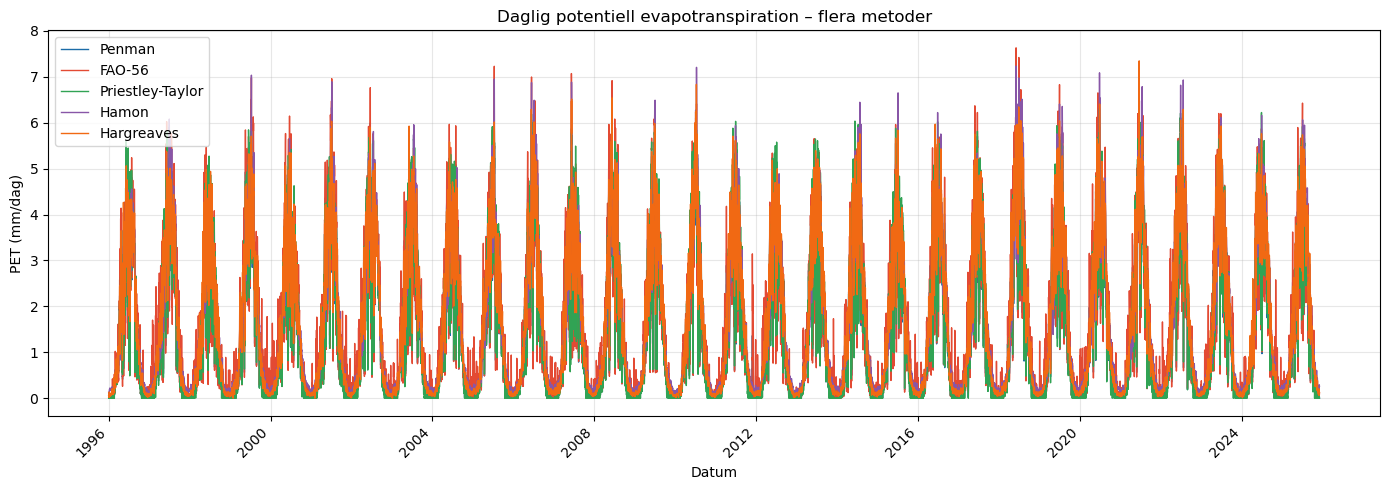

In [7]:
# urval av PET metoder
plot_methods = ["Penman", "FAO-56", "Priestley-Taylor", "Hamon", "Hargreaves"]
available_methods = [m for m in plot_methods if m in pet_results.columns]

colors = ["#1b6ca8", "#e34a33", "#31a354", "#8856a7", "#f16913"]

fig, ax = plt.subplots(figsize=(14, 5))

for method, color in zip(available_methods, colors):
    ax.plot(pet_results.index, pet_results[method], color=color, linewidth=1.0, label=method)

ax.set_title("Daglig potentiell evapotranspiration – flera metoder")
ax.set_xlabel("Datum")
ax.set_ylabel("PET (mm/dag)")
ax.legend(loc="upper left", framealpha=0.8)
ax.grid(alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()